In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Data Understanding

# 1: IMPORT LIBRARIES
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Time series analysis
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

# Settings
sns.set_style("whitegrid")




In [ ]:
# 2. LOAD DATA
df = pd.read_csv('/content/drive/MyDrive/Dissertation Dataset/walmart_clean2.csv')
df.head()


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,lag_1,lag_4,rolling_4,Month,Week
0,1,05/02/2010,1643690.90,0,42.31,2.572,211.096358,8.106,NaN,NaN,NaN,2,6
1,1,12/02/2010,1641957.44,1,38.51,2.548,211.242170,8.106,1643690.90,NaN,NaN,2,7
2,1,19/02/2010,1611968.17,0,39.93,2.514,211.289143,8.106,1641957.44,NaN,NaN,2,8
3,1,26/02/2010,1409727.59,0,46.63,2.561,211.319643,8.106,1611968.17,NaN,1576836.03,2,9
4,1,05/03/2010,1554806.68,0,46.50,2.625,211.350143,8.106,1409727.59,1643690.9,1554614.97,3,10


In [ ]:
# 3. DATA OVERVIEW
print("Shape of dataset:", df.shape)

df.info()

df.describe()


Shape of dataset: (6435, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
 8   lag_1         6434 non-null   float64
 9   lag_4         6431 non-null   float64
 10  rolling_4     6432 non-null   float64
 11  Month         6435 non-null   int64  
 12  Week          6435 non-null   int64  
dtypes: float64(8), int64(4), object(1)
memory usage: 653.7+ KB


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,lag_1,lag_4,rolling_4,Month,Week
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6.434000e+03,6.431000e+03,6.432000e+03,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151,1.047009e+06,1.047158e+06,1.046898e+06,6.447552,26.517483
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885,5.643992e+05,5.644889e+05,5.502971e+05,3.238308,14.217639
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000,2.099862e+05,2.099862e+05,2.319302e+05,1.000000,1.000000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000,5.531677e+05,5.528985e+05,5.582409e+05,4.000000,14.000000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000,9.608457e+05,9.609985e+05,9.689211e+05,6.000000,26.000000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000,1.420282e+06,1.420758e+06,1.417639e+06,9.000000,38.000000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000,3.818686e+06,3.818686e+06,2.938513e+06,12.000000,53.000000


In [ ]:
# 4. DATE CONVERSION & SORTING
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df = df.sort_values('Date')


In [ ]:
# 5. MISSING VALUES CHECK
df.isnull().sum()


,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0
lag_1,1
lag_4,4


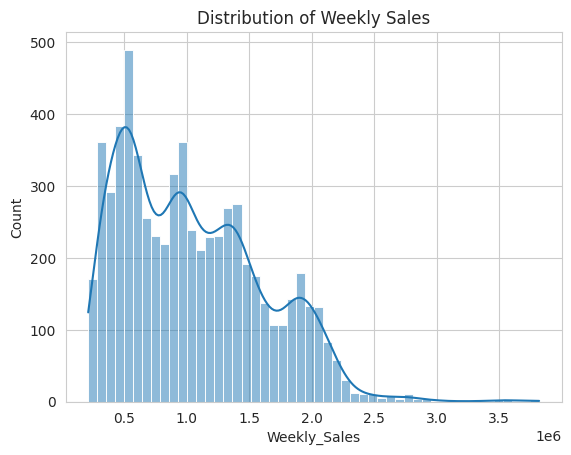

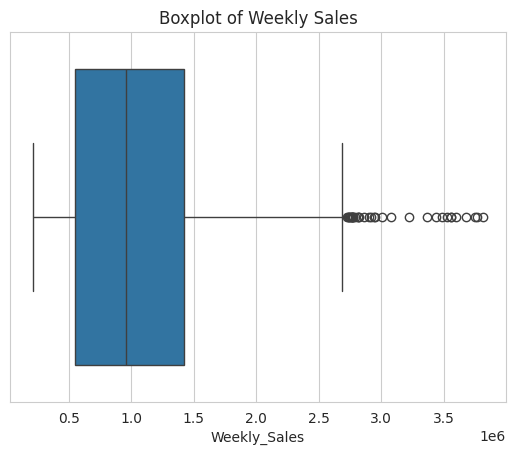

In [ ]:
#  6. UNIVARIATE ANALYSIS
# Distribution
plt.figure()
sns.histplot(df['Weekly_Sales'], bins=50, kde=True)
plt.title('Distribution of Weekly Sales')
plt.show()

# Boxplot (Outliers)
plt.figure()
sns.boxplot(x=df['Weekly_Sales'])
plt.title('Boxplot of Weekly Sales')
plt.show()


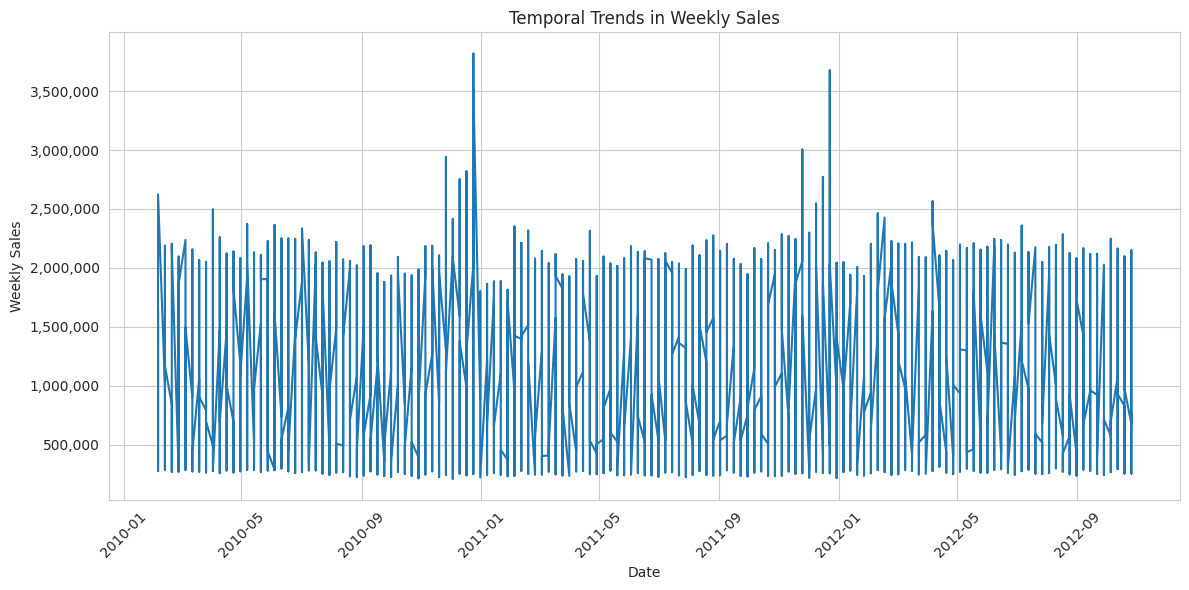

In [ ]:
# 7. TIME SERIES VISUALIZATION
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Weekly_Sales'])
plt.title('Temporal Trends in Weekly Sales')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')

# Removes scientific notation
plt.ticklabel_format(style='plain', axis='y')

import matplotlib.ticker as mtick
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


In [ ]:
# 8. FEATURE EXTRACTION (TIME FEATURES)
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week


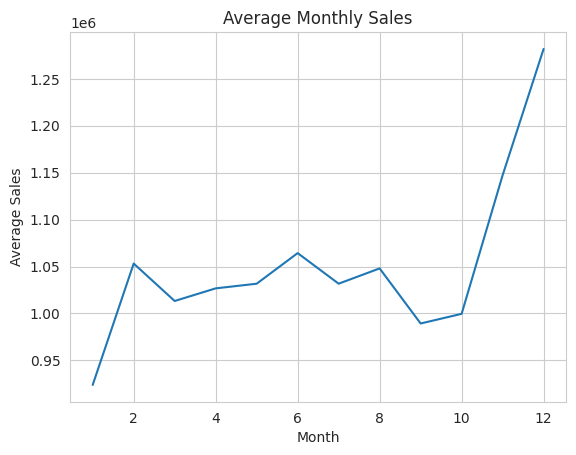

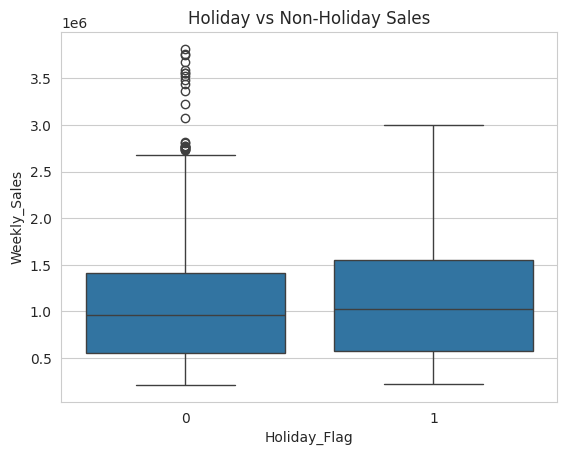

In [ ]:
# 9. SEASONALITY ANALYSIS
# Monthly Sales Pattern
monthly_sales = df.groupby('Month')['Weekly_Sales'].mean()

plt.figure()
monthly_sales.plot()
plt.title('Average Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.show()

# Holiday Effect
plt.figure()
sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=df)
plt.title('Holiday vs Non-Holiday Sales')
plt.show()


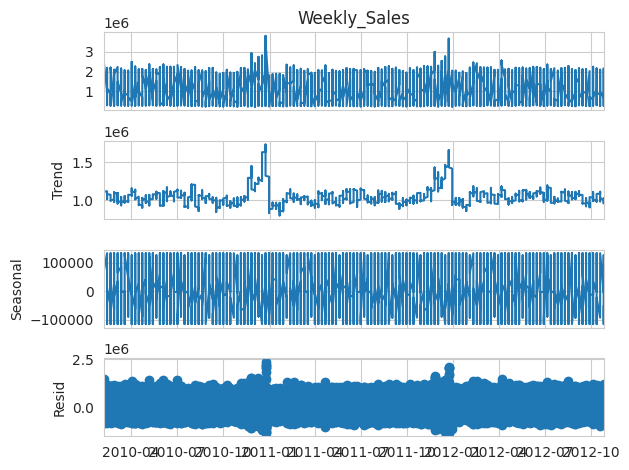

In [ ]:
# 10. TIME SERIES DECOMPOSITION (HIGH IMPACT)
df_ts = df.set_index('Date')

decomposition = seasonal_decompose(df_ts['Weekly_Sales'], model='additive', period=52)

decomposition.plot()
plt.show()


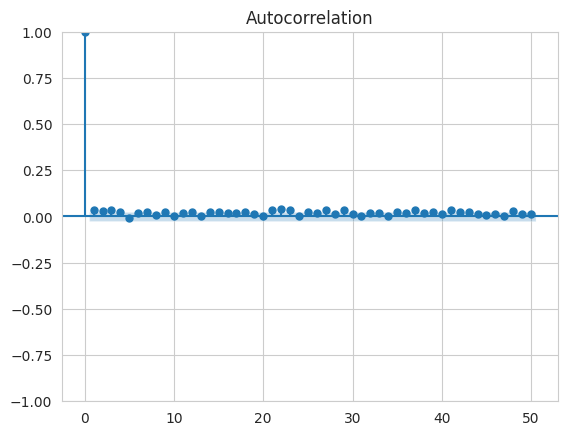

In [ ]:
# 11. AUTOCORRELATION (ACF)
plot_acf(df['Weekly_Sales'], lags=50)
plt.show()


In [ ]:
# 12. STATIONARITY TEST (ADF)
result = adfuller(df['Weekly_Sales'])

print('ADF Statistic:', result[0])
print('p-value:', result[1])


ADF Statistic: -11.521977286498133
p-value: 4.0195757853466524e-21


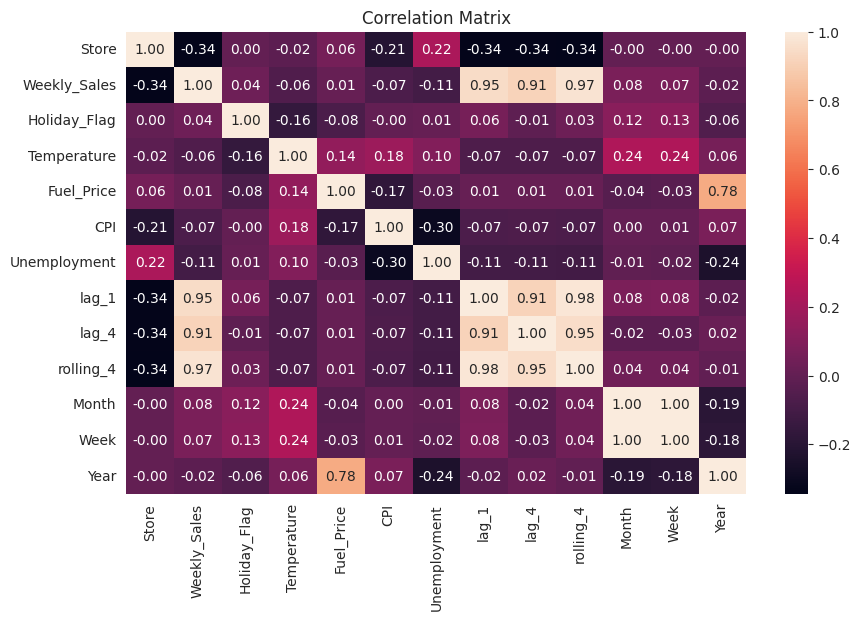

In [ ]:
# 13. CORRELATION MATRIX
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


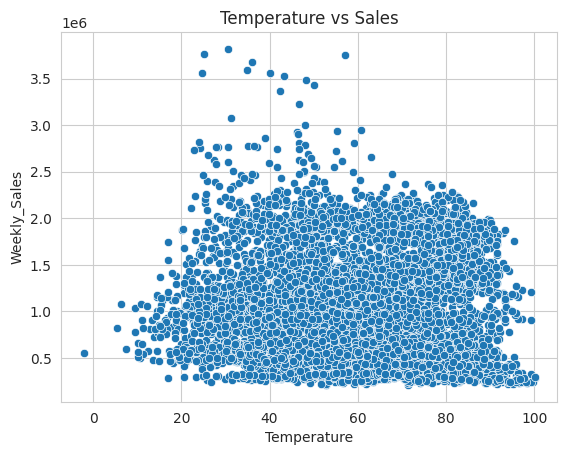

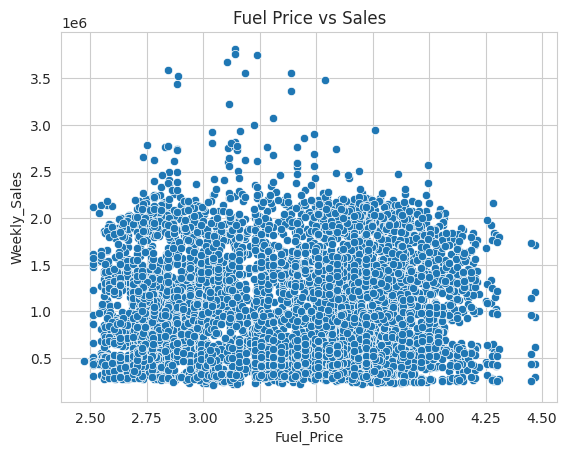

In [ ]:

# 14. RELATIONSHIP ANALYSIS (SCATTER)
sns.scatterplot(x='Temperature', y='Weekly_Sales', data=df)
plt.title('Temperature vs Sales')
plt.show()

sns.scatterplot(x='Fuel_Price', y='Weekly_Sales', data=df)
plt.title('Fuel Price vs Sales')
plt.show()


In [ ]:
# 15. OUTLIER DETECTION (IQR METHOD)
Q1 = df['Weekly_Sales'].quantile(0.25)
Q3 = df['Weekly_Sales'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['Weekly_Sales'] < (Q1 - 1.5 * IQR)) |
              (df['Weekly_Sales'] > (Q3 + 1.5 * IQR))]

print("Number of outliers:", outliers.shape[0])


Number of outliers: 34


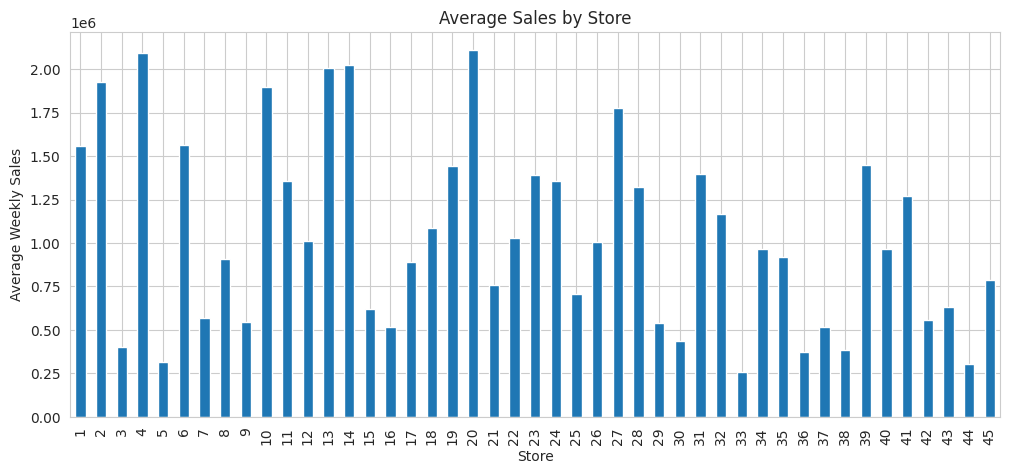

In [ ]:
# 16. GROUPED ANALYSIS (BY STORE)
store_sales = df.groupby('Store')['Weekly_Sales'].mean()

plt.figure(figsize=(12,5))
store_sales.plot(kind='bar')
plt.title('Average Sales by Store')
plt.xlabel('Store')
plt.ylabel('Average Weekly Sales')
plt.show()


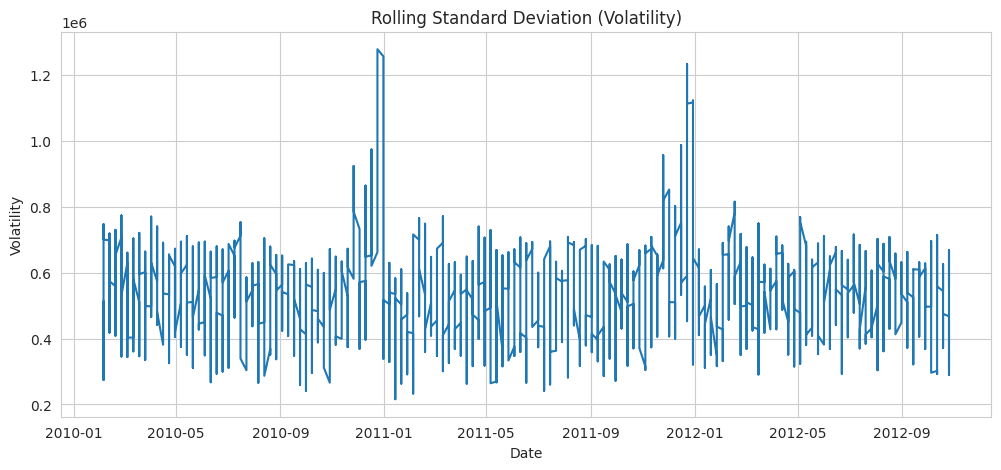

In [ ]:
# 17. VOLATILITY ANALYSIS (ROLLING STD)
rolling_std = df['Weekly_Sales'].rolling(window=12).std()

plt.figure(figsize=(12,5))
plt.plot(df['Date'], rolling_std)
plt.title('Rolling Standard Deviation (Volatility)')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()
